In [80]:
import os
import glob
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

### Data Import

In [2]:
DATA_DIR = "./analytics_data"

# Grab files for input, output
input_files = sorted(glob.glob(os.path.join(DATA_DIR, "train/input_2023_w*.csv"))) # Pre-release of ball data
output_files = sorted(glob.glob(os.path.join(DATA_DIR, "train/output_2023_w*.csv"))) # Post-release of ball data

# Put together all input, output data
input_data = pd.concat((pd.read_csv(p) for p in input_files), ignore_index=True)
output_data = pd.concat((pd.read_csv(p) for p in output_files), ignore_index = True)
sup_data = pd.read_csv(f"{DATA_DIR}/supplementary_data.csv")

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/544402945.py:10: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  sup_data = pd.read_csv(f"{DATA_DIR}/supplementary_data.csv")


In [8]:
# Merge input, output data with supplementary data on play_id
input_merged = input_data.merge(sup_data, on=['game_id', 'play_id'], how='left')
output_merged = input_data.merge(sup_data, on=['game_id', 'play_id'], how='left')

In [10]:
# Select Deep Passes as Plays of Interest
input_deep = input_merged.copy()
input_deep = input_deep[input_deep['pass_length'] > 19]
input_deep = input_deep.reset_index().drop('index', axis = 1)

output_deep = output_merged.copy()
output_deep = output_deep[output_deep['pass_length'] > 19]
output_deep = output_deep.reset_index().drop('index', axis = 1)

In [19]:
input_deep.columns

Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a',
       'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'season',
       'week', 'game_date', 'game_time_eastern', 'home_team_abbr',
       'visitor_team_abbr', 'play_description', 'quarter', 'game_clock',
       'down', 'yards_to_go', 'possession_team', 'defensive_team',
       'yardline_side', 'yardline_number', 'pre_snap_home_score',
       'pre_snap_visitor_score', 'play_nullified_by_penalty', 'pass_result',
       'pass_length', 'offense_formation', 'receiver_alignment',
       'route_of_targeted_receiver', 'play_action', 'dropback_type',
       'dropback_distance', 'pass_location_type', 'defenders_in_the_box',
       'team_coverage_man_zone', 'team_coverage_type', 'penalty_yards',
       'pre_

### Data Engineering

#### Make Wide Data

In [67]:
def get_play_by_id(game_id, play_id, input_data, output_data):
    input_subset = input_data.query("game_id == @game_id and play_id == @play_id")
    output_subset = output_data.query("game_id == @game_id and play_id == @play_id")
    
    return {'input': input_subset, 'output': output_subset}

def get_4_closest_defenders_at_release(play_data):

    # Grab the frame at which the ball was released for the play
    release_data = play_data['output']
    release_frame_id = release_data['frame_id'].min()
    release_frame = release_data[release_data['frame_id'] == release_frame_id]

    # Grab the targeted receiver data and his position on field
    tgt_rec = release_frame.query("player_role == 'Targeted Receiver'")
    if tgt_rec.empty:
        return []
    tgt_x, tgt_y = tgt_rec[['x', 'y']].iloc[0]

    # Grab all defenders data
    defenders = release_frame.query("player_role == 'Defensive Coverage'").copy()
    if defenders.empty:
        return []

    # Calculate distance of each defender from reciever, return only the names of the 4 closest
    defenders['dist_from_tgt_rec'] = np.hypot(defenders['x'] - tgt_x, defenders['y'] - tgt_y)
    return defenders.sort_values('dist_from_tgt_rec').head(4)['player_name'].tolist()

def process_frame(curr_frame_data, closest_4_defs, game_id, play_id, frame_id, to_release):
    # Creates one wide row for a given frame

    # Of the current frame data, grab the row for the current receiver
    tgt_rec = curr_frame_data.query("player_role == 'Targeted Receiver'")
    if tgt_rec.empty:
        return None
    tgt_rec = tgt_rec.iloc[0]

    # Add initial game, ball land, and receiver data
    row_dict = {
        'game_id': game_id,
        'play_id': play_id,
        'frame_id': frame_id,
        'to_release': to_release,
        'tgt_rec_name': tgt_rec['player_name'],
        'tgt_rec_x': tgt_rec['x'],
        'tgt_rec_y': tgt_rec['y'],
        'tgt_rec_s': tgt_rec['s'],
        'tgt_rec_a': tgt_rec['a'],
        'tgt_rec_o': tgt_rec['o'],
        'tgt_rec_dir': tgt_rec['dir'],
        'tgt_rec_ball_dist': np.hypot(tgt_rec['x'] - tgt_rec['ball_land_x'], tgt_rec['y'] - tgt_rec['ball_land_y']),
        'ball_land_x': tgt_rec['ball_land_x'],
        'ball_land_y': tgt_rec['ball_land_y'],
        'pass_result': tgt_rec['pass_result'],
        'complete': 1 if tgt_rec['pass_result'] == 'C' else 0,
        'play_description': tgt_rec['play_description'],
        'quarter': tgt_rec['quarter'],
        'game_clock': tgt_rec['game_clock'],
        'down': tgt_rec['down'],
        'yards_to_go': tgt_rec['yards_to_go'],
        'yardline_side': tgt_rec['yardline_side'],
        'yardline_number': tgt_rec['yardline_number'],
        'home_team_abbr': tgt_rec['home_team_abbr'],
        'visitor_team_abbr': tgt_rec['visitor_team_abbr'],
        'possession_team': tgt_rec['possession_team'],
        'pre_snap_home_score': tgt_rec['pre_snap_home_score'],
        'pre_snap_visitor_score': tgt_rec['pre_snap_visitor_score'],
        'pass_length': tgt_rec['pass_length'],
        'offense_formation': tgt_rec['offense_formation'],
        'receiver_alignment': tgt_rec['receiver_alignment'],
        'route_of_targeted_receiver': tgt_rec['route_of_targeted_receiver'],
        'pass_location_type': tgt_rec['pass_location_type'],
        'team_coverage_man_zone': tgt_rec['team_coverage_man_zone'],
        'team_coverage_type': tgt_rec['team_coverage_type'],
        'yards_gained': tgt_rec['yards_gained']
    }

    # Get list of defenders that are in the closest 4 defenders
    defenders = curr_frame_data.query(
        "player_role == 'Defensive Coverage' and player_name in @closest_4_defs"
    ).copy()

    if defenders.empty:
        return row_dict

    # Calculate distance from targeted receiver for defenders
    defenders['dist_from_tgt_rec'] = np.hypot(
        defenders['x'] - tgt_rec['x'],
        defenders['y'] - tgt_rec['y']
    )

    # Calculate distance from ball for defenders
    defenders['dist_from_ball'] = np.hypot(
        defenders['x'] - tgt_rec['ball_land_x'],
        defenders['y'] - tgt_rec['ball_land_y']
    )

    # Sort defenders by distance from targeted receiver
    defenders = defenders.sort_values('dist_from_tgt_rec').reset_index(drop=True)

    # Add closest 4 defenders’ info
    for i in range(4):
        prefix = f'def_{i+1}_'
        if i < len(defenders):
            d = defenders.iloc[i]
            row_dict.update({
                prefix + 'name': d['player_name'],
                prefix + 'x': d['x'],
                prefix + 'y': d['y'],
                prefix + 's': d['s'],
                prefix + 'a': d['a'],
                prefix + 'o': d['o'],
                prefix + 'dir': d['dir'],
                prefix + 'dist': d['dist_from_tgt_rec'],
                prefix + 'ball_dist': d['dist_from_ball']
            })
        else:
            row_dict.update({
                prefix + k: np.nan for k in
                ['name', 'x', 'y', 's', 'a', 'o', 'dir', 'dist', 'ball_dist']
            })

    return row_dict

def make_wide_data(input_data, output_data):
    rows = []

    # Grab all unique plays in dataset
    unique_plays = input_data[['game_id', 'play_id']].drop_duplicates().itertuples(index=False)

    # For each unique play in dataset
    for game_id, play_id in unique_plays:

        # Get data for current play, 4 closest defenders at ball release
        play_data = get_play_by_id(game_id, play_id, input_data, output_data)
        closest_4_defs = get_4_closest_defenders_at_release(play_data)
        if not closest_4_defs:
            continue

        # Process pre-release (input) frames
        for frame_id, frame_group in play_data['input'].groupby('frame_id'):
            row_dict = process_frame(frame_group, closest_4_defs, game_id, play_id, frame_id, 'before')
            if row_dict:
                rows.append(row_dict)

        # Process post-release (output) frames
        for frame_id, frame_group in play_data['output'].groupby('frame_id'):
            row_dict = process_frame(frame_group, closest_4_defs, game_id, play_id, frame_id, 'after')
            if row_dict:
                rows.append(row_dict)

    return pd.DataFrame(rows)

In [68]:
wide_data = make_wide_data(input_deep, output_deep)

In [69]:
wide_data.to_csv('wide_data.csv', index=False)

#### Load Wide Data

In [70]:
wide_data = pd.read_csv('wide_data.csv')

In [71]:
wide_data.columns

Index(['game_id', 'play_id', 'frame_id', 'to_release', 'tgt_rec_name',
       'tgt_rec_x', 'tgt_rec_y', 'tgt_rec_s', 'tgt_rec_a', 'tgt_rec_o',
       'tgt_rec_dir', 'tgt_rec_ball_dist', 'ball_land_x', 'ball_land_y',
       'pass_result', 'complete', 'play_description', 'quarter', 'game_clock',
       'down', 'yards_to_go', 'yardline_side', 'yardline_number',
       'home_team_abbr', 'visitor_team_abbr', 'possession_team',
       'pre_snap_home_score', 'pre_snap_visitor_score', 'pass_length',
       'offense_formation', 'receiver_alignment', 'route_of_targeted_receiver',
       'pass_location_type', 'team_coverage_man_zone', 'team_coverage_type',
       'yards_gained', 'def_1_name', 'def_1_x', 'def_1_y', 'def_1_s',
       'def_1_a', 'def_1_o', 'def_1_dir', 'def_1_dist', 'def_1_ball_dist',
       'def_2_name', 'def_2_x', 'def_2_y', 'def_2_s', 'def_2_a', 'def_2_o',
       'def_2_dir', 'def_2_dist', 'def_2_ball_dist', 'def_3_name', 'def_3_x',
       'def_3_y', 'def_3_s', 'def_3_a', 'def_3_

#### Add Advanced Features

In [114]:
def add_advanced_features(df):
    df = df.copy();
    dt = 0.1 # one frame per 1/10th second

    # Theta, Velocity Components =================================
    # Receiver: Theta, Velocity Components
    theta = np.deg2rad(df['tgt_rec_dir'])
    df['tgt_rec_vx'] = df['tgt_rec_s'] * np.cos(theta)
    df['tgt_rec_vy'] = df['tgt_rec_s'] * np.sin(theta)

    # Defenders: Theta, Velocity Components
    for n in range(1, 5):
        th = np.deg2rad(df[f'def_{n}_dir'])
        df[f'def_{n}_vx'] = df[f'def_{n}_s'] * np.cos(th)
        df[f'def_{n}_vy'] = df[f'def_{n}_s'] * np.sin(th)
        

    # Unit Vector to Ball (Receiver and Defenders) ===============
    def compute_u_ball(prefix):
        ux = df['ball_land_x'] - df[f'{prefix}_x']
        uy = df['ball_land_y'] - df[f'{prefix}_y']
        dist = np.hypot(ux, uy)
        dist[dist == 0] = 1e-9
        df[f'{prefix}_u_ball_x'] = ux / dist
        df[f'{prefix}_u_ball_y'] = uy / dist
        df[f'{prefix}_ball_dist'] = dist

    compute_u_ball("tgt_rec")
    for n in range(1, 5):
        compute_u_ball(f"def_{n}")



    # Velocity Toward Ball =======================================
    # Receiver Velocity Toward Ball
    df['tgt_rec_v_toward_ball'] = (
        df['tgt_rec_vx'] * df['tgt_rec_u_ball_x'] +
        df['tgt_rec_vy'] * df['tgt_rec_u_ball_y']
    )

    # Defenders Velocity Toward Ball
    for n in range(1, 5):
        df[f'def_{n}_v_toward_ball'] = (
            df[f'def_{n}_vx'] * df[f'def_{n}_u_ball_x'] +
            df[f'def_{n}_vy'] * df[f'def_{n}_u_ball_y']
        )


    # Closing Speed to Ball (pos = closing) =======================
    # Receiver Closing Speed to Ball
    df['tgt_rec_closing_speed_ball'] = (
        df.groupby(['game_id','play_id'])['tgt_rec_ball_dist'].diff(1) / dt
    )

    # Defenders Closingn Speed to Ball
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_ball'] = (
            df.groupby(['game_id','play_id'])[f'def_{n}_ball_dist'].diff(1) / dt
        )

    
    # Momentum Advantage: Receiver vs. Defender ===================
    for n in range(1, 5):
        df[f'def_{n}_momentum_adv'] = (
            df['tgt_rec_v_toward_ball'] - df[f'def_{n}_v_toward_ball']
        )

    
    # Closing Speed: Defender to Receiver =========================
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_rec'] = (
            df.groupby(['game_id','play_id'])[f'def_{n}_dist'].diff(1) / dt
        )

    
    # MIN & MEAN Separation: All Defenders ========================
    dmat = df[[f'def_{i}_dist' for i in range(1, 5)]].values
    df['min_separation_all_def'] = np.min(dmat, axis=1)
    df['mean_separation_closest_3_defs'] = np.sort(dmat, axis=1)[:, :3].mean(axis=1)

    
    # Angle Defender Motion vs. Receiver Motion ===================
    rec_speed_mag = np.hypot(df['tgt_rec_vx'], df['tgt_rec_vy'])

    for n in range(1, 5):
        dot = df[f'def_{n}_vx'] * df['tgt_rec_vx'] + df[f'def_{n}_vy'] * df['tgt_rec_vy']
        den = (
            np.hypot(df[f'def_{n}_vx'], df[f'def_{n}_vy']) *
            rec_speed_mag
        ).clip(1e-8)
        df[f'def_{n}_angle_rec_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )


    # Angle Defender Motion vs. Ball Direction ===================
    for n in range(1, 5):
        dot = (
            df[f'def_{n}_vx'] * df[f'def_{n}_u_ball_x'] +
            df[f'def_{n}_vy'] * df[f'def_{n}_u_ball_y']
        )
        den = np.hypot(df[f'def_{n}_vx'], df[f'def_{n}_vy']).clip(1e-8)
        df[f'def_{n}_angle_ball_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )


    # Time to Ball: Receiver and Defenders =======================
    # Time to Ball - Receiver
    eps = 1e-6
    df['tgt_rec_t_to_ball'] = df['tgt_rec_ball_dist'] / df['tgt_rec_s'].clip(lower=eps)

    # Time to Ball - Defenders
    for n in range(1, 5):
        df[f'def_{n}_t_to_ball'] = (
            df[f'def_{n}_ball_dist'] / df[f'def_{n}_s'].clip(lower=eps)
        )

    df['min_t_def_to_ball'] = df[[f'def_{n}_t_to_ball' for n in range(1,5)]].min(axis=1)
    df['min_t_def_minus_t_rec'] = df['min_t_def_to_ball'] - df['tgt_rec_t_to_ball']


    # Crowdedness =================================================
    eps = 1e-3
    dist_cols = [f'def_{n}_dist' for n in range(1, 5)]
    df['crowdedness'] = (1.0 / (df[dist_cols] + eps)).sum(axis=1)


    # Acceleration Toward Ball - Receiver =========================
    th = np.deg2rad(df['tgt_rec_dir'])
    ax = df['tgt_rec_a'] * np.cos(th)
    ay = df['tgt_rec_a'] * np.sin(th)

    df['tgt_rec_a_toward_ball'] = (
        ax * df['tgt_rec_u_ball_x'] +
        ay * df['tgt_rec_u_ball_y']
    )


    # Defender In Phase ===========================================
    rec_dir_rad = np.deg2rad(df['tgt_rec_dir'])

    for n in range(1, 5):
        def_dir_rad = np.deg2rad(df[f'def_{n}_dir'])
        df[f'def_{n}_in_phase'] = np.cos(def_dir_rad - rec_dir_rad)


    # Angle Between Closest Two Defenders to Receiver =============

    # Compute Vectors from Receiver to each defender, distances
    for n in range(1, 5):
        df[f"dx_def{n}"] = df[f"def_{n}_x"] - df["tgt_rec_x"]
        df[f"dy_def{n}"] = df[f"def_{n}_y"] - df["tgt_rec_y"]
        df[f"dist_def{n}"] = np.hypot(df[f"dx_def{n}"], df[f"dy_def{n}"])

    # Identify Closest 2 Defenders
    dist_cols = ['dist_def1', 'dist_def2', 'dist_def3', 'dist_def4']
    dx_cols   = ['dx_def1', 'dx_def2', 'dx_def3', 'dx_def4']
    dy_cols   = ['dy_def1', 'dy_def2', 'dy_def3', 'dy_def4']

    closest_defenders_angles = []

    for i in range(len(df)):
        # Get distances for each defender for current frame
        d1 = df['dist_def1'].iat[i]
        d2 = df['dist_def2'].iat[i]
        d3 = df['dist_def3'].iat[i]
        d4 = df['dist_def4'].iat[i]

        dists = [d1, d2, d3, d4]

        # Get indicies of closest 2 defenders
        first_idx = dists.index(min(dists))

        rem_indices = [0, 1, 2, 3]
        rem_indices.remove(first_idx)
        rem_dists = [dists[j] for j in rem_indices]
        second_idx = rem_indices[rem_dists.index(min(rem_dists))]

        # Get dx, dy for two closest defenders
        dx_list = [df['dx_def1'].iat[i], df['dx_def2'].iat[i], df['dx_def3'].iat[i], df['dx_def4'].iat[i]]
        dy_list = [df['dy_def1'].iat[i], df['dy_def2'].iat[i], df['dy_def3'].iat[i], df['dy_def4'].iat[i]]

        dx1 = dx_list[first_idx]
        dy1 = dy_list[first_idx]
        dx2 = dx_list[second_idx]
        dy2 = dy_list[second_idx]

        # Compute angle between two vectors
        dot = dx1 * dx2 + dy1 * dy2
        mag1 = np.hypot(dx1, dy1)
        mag2 = np.hypot(dx2, dy2)
        denom = max(mag1 * mag2, 1e-9)
        cos_angle = np.clip(dot / denom, -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_angle))

        closest_defenders_angles.append(angle_deg)

    df['closest_2_def_angle_diff'] = closest_defenders_angles


    # Rank defenders per frame by distance to receiver and create def_close features =================
    N = len(df)

    # List of unranked columns to create ranked columns for
    features_to_rank = [
        # distances
        'def_1_dist', 'def_2_dist', 'def_3_dist', 'def_4_dist',
        # ball distances
        'def_1_ball_dist', 'def_2_ball_dist', 'def_3_ball_dist', 'def_4_ball_dist',
        # v_toward_ball
        'def_1_v_toward_ball', 'def_2_v_toward_ball', 'def_3_v_toward_ball', 'def_4_v_toward_ball',
        # closing_speed_ball
        'def_1_closing_speed_ball', 'def_2_closing_speed_ball', 'def_3_closing_speed_ball', 'def_4_closing_speed_ball',
        # closing_speed_rec
        'def_1_closing_speed_rec', 'def_2_closing_speed_rec', 'def_3_closing_speed_rec', 'def_4_closing_speed_rec',
        # t_to_ball
        'def_1_t_to_ball', 'def_2_t_to_ball', 'def_3_t_to_ball', 'def_4_t_to_ball',
        # momentum
        'def_1_momentum_adv', 'def_2_momentum_adv', 'def_3_momentum_adv', 'def_4_momentum_adv',
        # angles rec
        'def_1_angle_rec_deg', 'def_2_angle_rec_deg', 'def_3_angle_rec_deg', 'def_4_angle_rec_deg',
        # angles ball
        'def_1_angle_ball_deg', 'def_2_angle_ball_deg', 'def_3_angle_ball_deg', 'def_4_angle_ball_deg',
        # in_phase
        'def_1_in_phase', 'def_2_in_phase', 'def_3_in_phase', 'def_4_in_phase',
        # vx, vy
        'def_1_vx', 'def_2_vx', 'def_3_vx', 'def_4_vx',
        'def_1_vy', 'def_2_vy', 'def_3_vy', 'def_4_vy',
    ]

    # Takes list of 4 columns, returns an array of just those columns
    def build_matrix(base_cols):
        return np.column_stack([df[c].values for c in base_cols])

    # Groupings of columns to rank
    grouped = [
        features_to_rank[0:4],    # def_*_dist
        features_to_rank[4:8],    # def_*_ball_dist
        features_to_rank[8:12],   # def_*_v_toward_ball
        features_to_rank[12:16],  # def_*_closing_speed_ball
        features_to_rank[16:20],  # def_*_closing_speed_rec
        features_to_rank[20:24],  # def_*_t_to_ball
        features_to_rank[24:28],  # def_*_momentum_adv
        features_to_rank[28:32],  # def_*_angle_rec_deg
        features_to_rank[32:36],  # def_*_angle_ball_deg
        features_to_rank[36:40],  # def_*_in_phase
        features_to_rank[40:44],  # def_*_vx
        features_to_rank[44:48],  # def_*_vy
    ]

    # Create a distance matrix to use to determine ordering
    dist_matrix = build_matrix(grouped[0])

    # Get indices of defenders sorted by distance (ascending)
    order = np.argsort(dist_matrix, axis = 1)

    # Reorders a matrix according to 'order', outputs def_closeN cols
    def reorder_and_assign(mat, prefix):
        # Takes N x 4 Matrix of Unranked Columns, and a prefix format
        
        # mat[row, order[row,:]] gives reordered values, but we can do fancy indexing:
        rows = np.arange(mat.shape[0])[:, None]  # shape (N,1)
        reordered = mat[rows, order]             # shape (N,4)
        # assign into df
        for j in range(4):
            df[f'{prefix.format(j+1)}'] = reordered[:, j]

    # Perform reordering of each gruop and assign def_close columns
    reorder_and_assign(build_matrix(grouped[0]), 'def_close{}_dist')
    reorder_and_assign(build_matrix(grouped[1]), 'def_close{}_ball_dist')
    reorder_and_assign(build_matrix(grouped[2]), 'def_close{}_v_toward_ball')
    reorder_and_assign(build_matrix(grouped[3]), 'def_close{}_closing_speed_ball')
    reorder_and_assign(build_matrix(grouped[4]), 'def_close{}_closing_speed_rec')
    reorder_and_assign(build_matrix(grouped[5]), 'def_close{}_t_to_ball')
    reorder_and_assign(build_matrix(grouped[6]), 'def_close{}_momentum_adv')
    reorder_and_assign(build_matrix(grouped[7]), 'def_close{}_angle_rec_deg')
    reorder_and_assign(build_matrix(grouped[8]), 'def_close{}_angle_ball_deg')
    reorder_and_assign(build_matrix(grouped[9]), 'def_close{}_in_phase')
    reorder_and_assign(build_matrix(grouped[10]), 'def_close{}_vx')
    reorder_and_assign(build_matrix(grouped[11]), 'def_close{}_vy')

    return df

In [115]:
data_adv = add_advanced_features(wide_data)

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/4231678584.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{prefix.format(j+1)}'] = reordered[:, j]
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/4231678584.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{prefix.format(j+1)}'] = reordered[:, j]
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/4231678584.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

In [116]:
data_adv.to_csv('data_adv.csv', index=False)

In [117]:
data_adv = pd.read_csv('data_adv.csv')

#### Filter to Useful Features

In [ ]:
useful_cols = ['game_id', 'play_id', 'frame_id', 'to_release',
               'tgt_rec_name', 'tgt_rec_x', 'tgt_rec_y', 'tgt_rec_o', 'tgt_rec_dir',
               'tgt_rec_ball_dist', 'ball_land_x', 'ball_land_y', 'pass_result',
               'complete', 'play_description', 'quarter', 'game_clock', 'down', 'yards_to_go',
               'yardline_side', 'yardline_number', 'home_team_abbr', 'visitor_team_abbr',
               'possession_team', 'pre_snap

#### Visualize Data

In [118]:
list(data_adv.columns)

['game_id',
 'play_id',
 'frame_id',
 'to_release',
 'tgt_rec_name',
 'tgt_rec_x',
 'tgt_rec_y',
 'tgt_rec_s',
 'tgt_rec_a',
 'tgt_rec_o',
 'tgt_rec_dir',
 'tgt_rec_ball_dist',
 'ball_land_x',
 'ball_land_y',
 'pass_result',
 'complete',
 'play_description',
 'quarter',
 'game_clock',
 'down',
 'yards_to_go',
 'yardline_side',
 'yardline_number',
 'home_team_abbr',
 'visitor_team_abbr',
 'possession_team',
 'pre_snap_home_score',
 'pre_snap_visitor_score',
 'pass_length',
 'offense_formation',
 'receiver_alignment',
 'route_of_targeted_receiver',
 'pass_location_type',
 'team_coverage_man_zone',
 'team_coverage_type',
 'yards_gained',
 'def_1_name',
 'def_1_x',
 'def_1_y',
 'def_1_s',
 'def_1_a',
 'def_1_o',
 'def_1_dir',
 'def_1_dist',
 'def_1_ball_dist',
 'def_2_name',
 'def_2_x',
 'def_2_y',
 'def_2_s',
 'def_2_a',
 'def_2_o',
 'def_2_dir',
 'def_2_dist',
 'def_2_ball_dist',
 'def_3_name',
 'def_3_x',
 'def_3_y',
 'def_3_s',
 'def_3_a',
 'def_3_o',
 'def_3_dir',
 'def_3_dist',
 'def

In [77]:
wide_data['route_of_targeted_receiver'].value_counts()

route_of_targeted_receiver
GO        52406
POST      23024
CORNER    17944
CROSS     12176
IN         5550
HITCH      4554
OUT        2968
WHEEL      1168
SLANT       636
FLAT        474
SCREEN      110
Name: count, dtype: int64

In [95]:
complete_go = wide_data[(wide_data['complete'] == 0) &
          (wide_data['route_of_targeted_receiver'] == 'GO')]

In [96]:
unique_complete_go_pairs = complete_go[['game_id', 'play_id']].drop_duplicates()

In [97]:
unique_complete_go_pairs.head()

,game_id,play_id
694,2023091000,3078
774,2023091000,3369
1170,2023091002,1412
1296,2023091002,2942
1342,2023091002,3812


In [91]:
def plot_play_distances(data, game_id, play_id):
    play = data[(data['game_id'] == game_id) & (data['play_id'] == play_id)]
    play = play.sort_values("frame_id").reset_index(drop=True)

    def_cols = [col for col in data.columns if col.startswith("def_")]

    def_ball_cols = [c for c in def_cols if c.endswith("ball_dist")]
    def_rec_dist_cols = [c for c in def_cols if c.endswith("_dist") and not c.endswith("ball_dist")]

    plt.figure(figsize=(12, 7))

    plt.plot(
        play["frame_id"],
        play["tgt_rec_ball_dist"],
        linewidth = 2,
        label = "Receiver Ball Dist",
    )

    for col in def_ball_cols:
        plt.plot(play["frame_id"], play[col], linestyle="--", label=col)

    for col in def_rec_dist_cols:
        plt.plot(play["frame_id"], play[col], linestyle=":", label=col)

    plt.xlabel("Frame")
    plt.ylabel("Distance (yards)")
    plt.title(f"Play Distance Over Time\nGame {game_id}, Play {play_id}")
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.0))
    plt.tight_layout()
    plt.show()

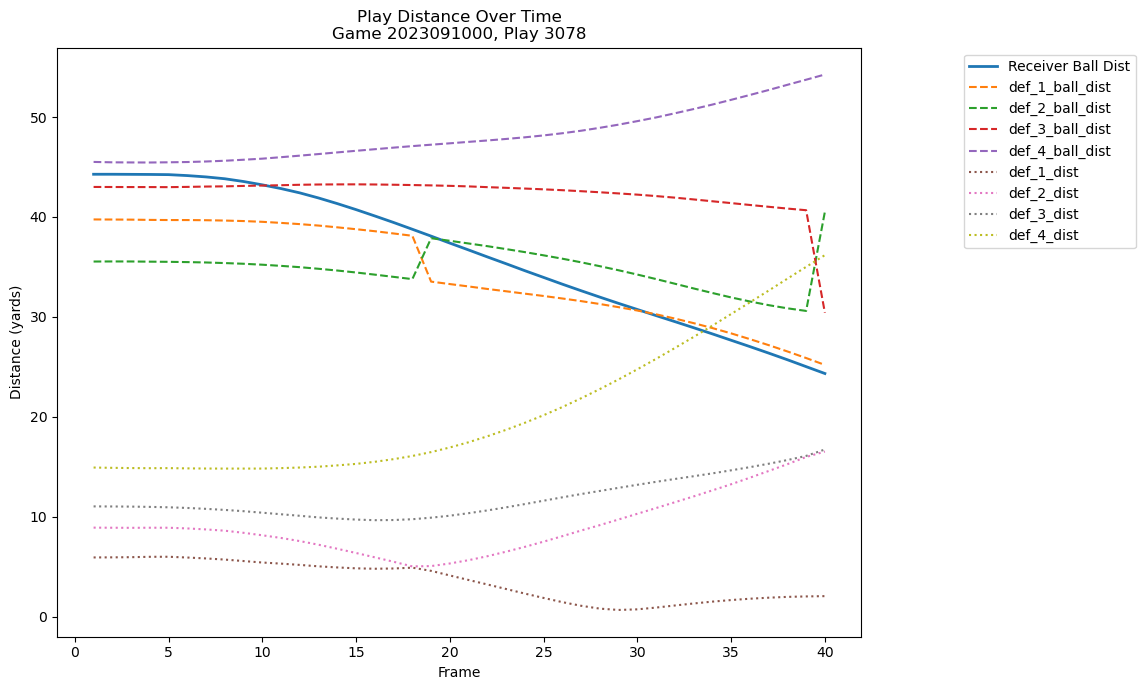

In [98]:
plot_play_distances(wide_data, 2023091000, 3078)